# Menyelesaikan masalah institusi pendidikan

# 1. Persiapan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/muhammadmirzaralfie/student-performance/data.csv", sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 2. Data Understanding

In [3]:
print(df.shape)
df.info()
df.describe()

(4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 n

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Seluruh data sudah dalam bentuk numerik kemungkinan karena sudah di encoding sejak awal

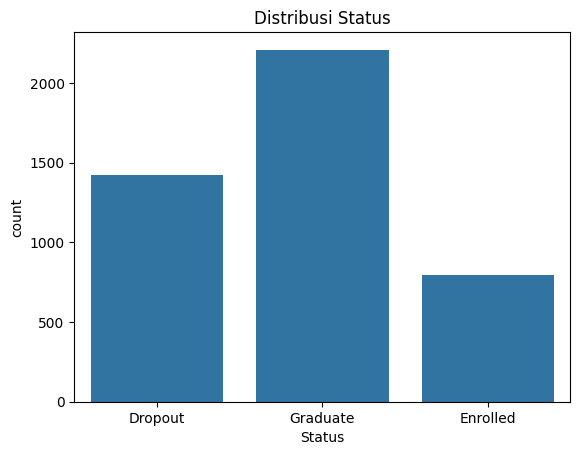

In [5]:
sns.countplot(x='Status', data=df)
plt.title("Distribusi Status")
plt.show()

karena tujuan utama analisa projek ini adalah prediksi Dropout, maka data target akan diubah menjadi binary yaitu dropout: 1, dan tidak dropout : 0

In [6]:
df['Status'] = df['Status'].map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})

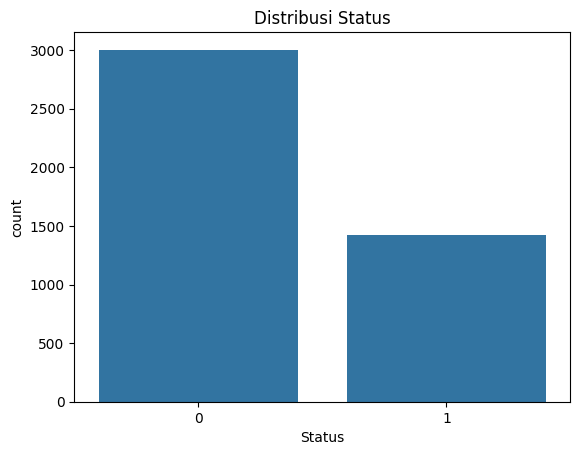

In [7]:
sns.countplot(x='Status', data=df)
plt.title("Distribusi Status")
plt.show()

walaupun sudah diubah menjadi binary, distribusi target nya masih imbalance walaupun tidak extreme

In [8]:
drop_cols = [col for col in df.columns if "2nd sem" in col]
df = df.drop(columns=drop_cols)

Dilakukan drop untuk kolom 2nd sem karena berpotensi terjadi data leakage yang menyebabkan model tidak optimal

## EDA Numerikal

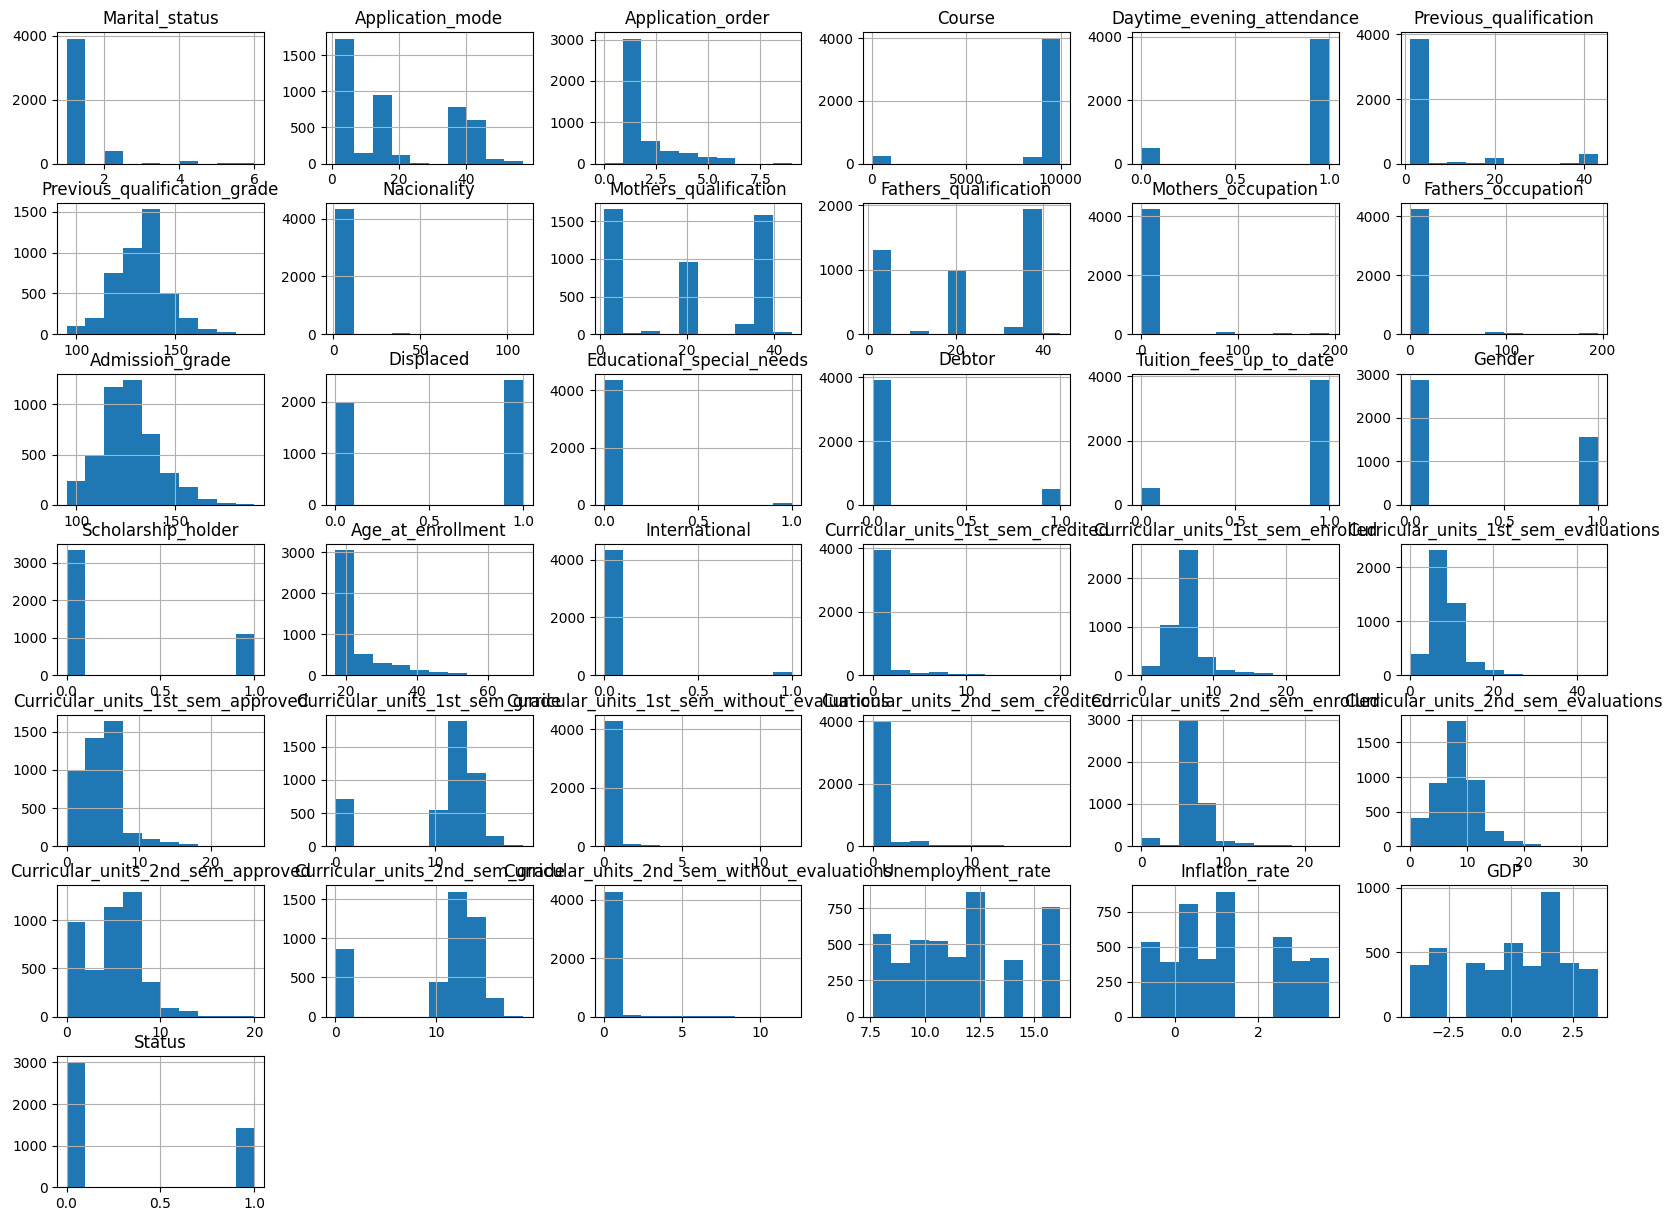

In [16]:
num_cols = df.select_dtypes(include=np.number).columns


df[num_cols].hist(figsize=(20, 15)) 
plt.show()

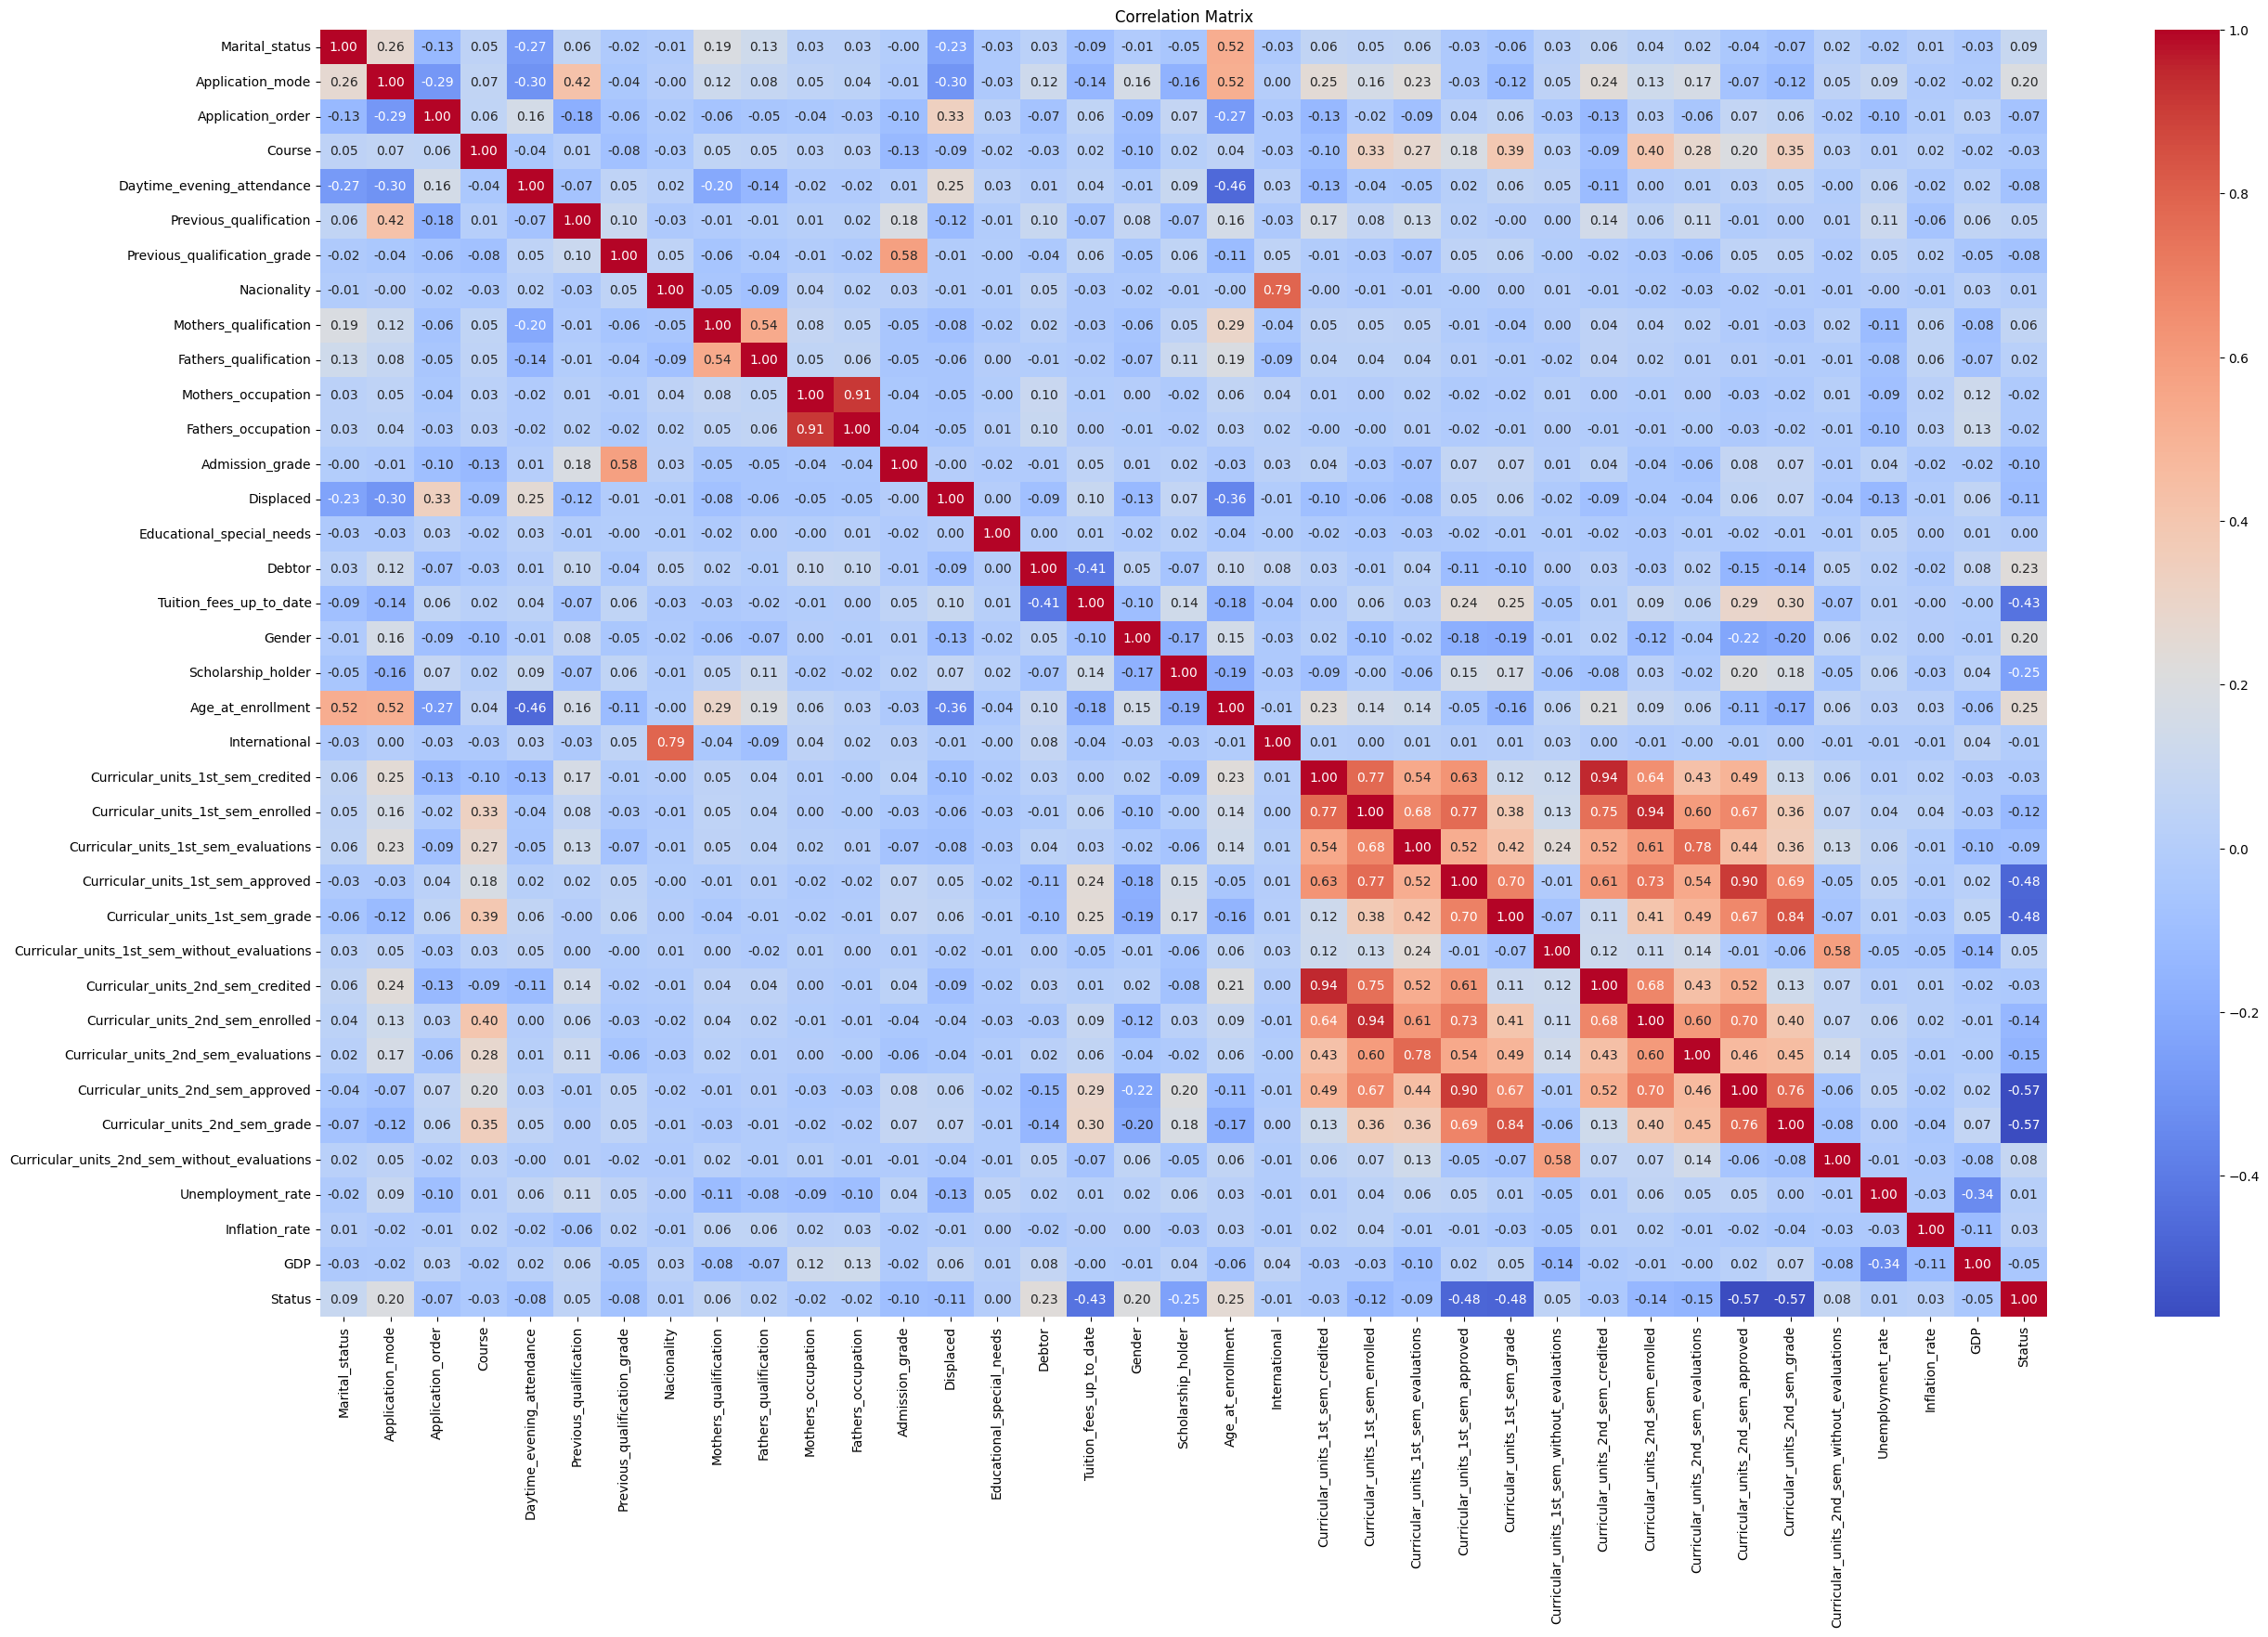

In [19]:
plt.figure(figsize=(30, 18))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Beberapa fitur memiliki korelasi yang sangat tinggi (>0.8) sehingga berpotensi untuk di drop supaya melakukan reduksi dimensional

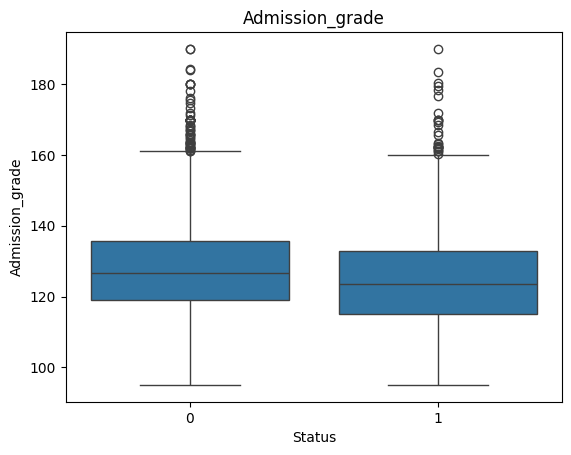

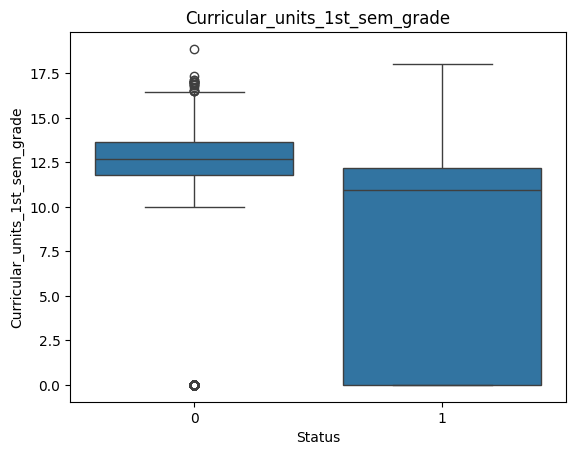

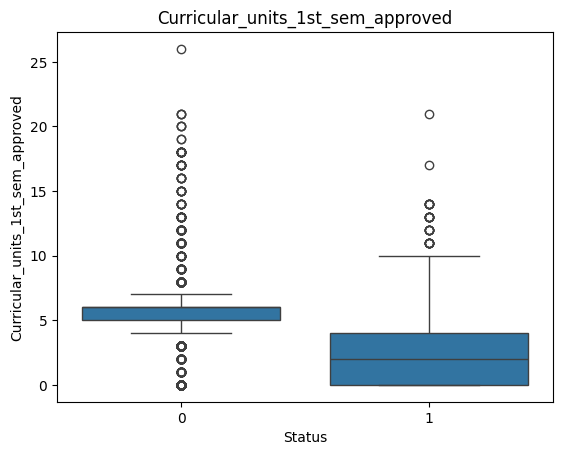

In [22]:
key_features = [
    'Admission_grade',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_approved'
]

for col in key_features:
    sns.boxplot(x='Status', y=col, data=df)
    plt.title(col)
    plt.show()

Beberapa data memiliki outlier

## 3. Preprocessing

In [26]:
df['success_rate'] = (
    df['Curricular_units_1st_sem_grade'] /
    df['Curricular_units_1st_sem_approved']
).replace([np.inf, -np.inf], 0).fillna(0)

Membuat fitur baru yaitu succes_rate sebagai feature engineering

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [29]:
X = df.drop('Status', axis=1)
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Scaaling supaya meningkatkan performa model

## 4.Modeling

In [31]:
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print("Baseline F1:", f1_score(y_test, y_pred_base))

Baseline F1: 0.8062015503875969


In [33]:
rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=10,
    scoring='recall',  
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

## 5.Evaluation

In [34]:
y_pred = best_model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Cohen Kappa:", cohen_kappa_score(y_test, y_pred))

Accuracy: 0.880225988700565
Precision: 0.8771186440677966
Recall: 0.7288732394366197
F1: 0.7961538461538461
Cohen Kappa: 0.7123733719247467


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92       601
           1       0.88      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885



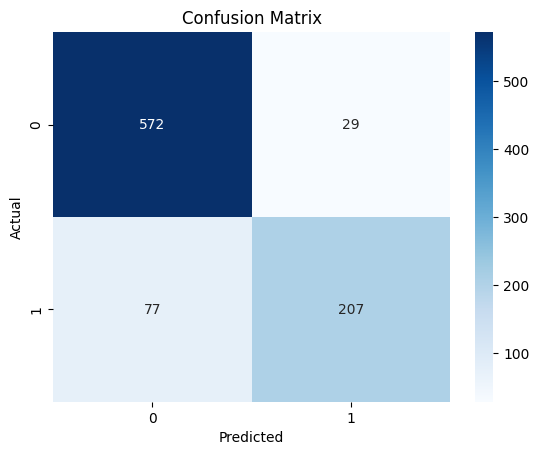

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Random Forest berhasil menjadi model yang optimal dengan akurasi mencapai 88%

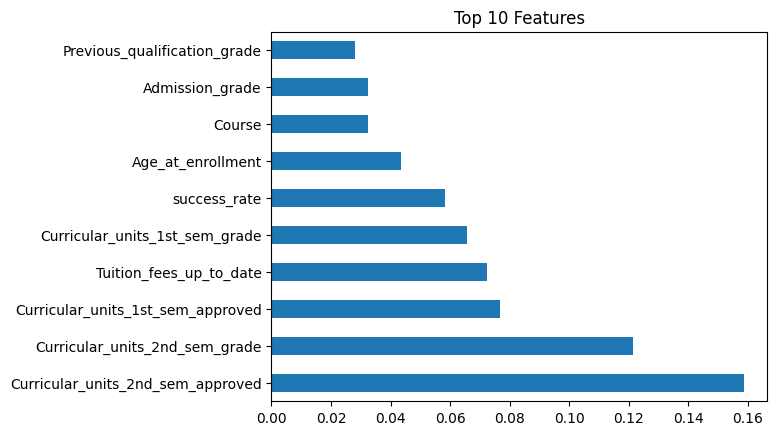

In [38]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10).plot(kind='barh')
plt.title("Top 10 Features")
plt.show()

Fitur yang paling berpengaruh dalam kualitas model menggunakn RF Feature Importance

In [39]:
joblib.dump(best_model, "model_dropout.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
model = joblib.load("model_dropout.pkl")
scaler = joblib.load("scaler.pkl")